In [1]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("taxis")
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [3]:
df.dtypes

pickup             datetime64[us]
dropoff            datetime64[us]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                         str
payment                       str
pickup_zone                   str
dropoff_zone                  str
pickup_borough                str
dropoff_borough               str
dtype: object

In [5]:
categorical_cols = [
    'payment',
    'pickup_zone',
    'dropoff_zone',
    'pickup_borough',
    'dropoff_borough'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [7]:
df['pickup'] = pd.to_datetime(df['pickup'])

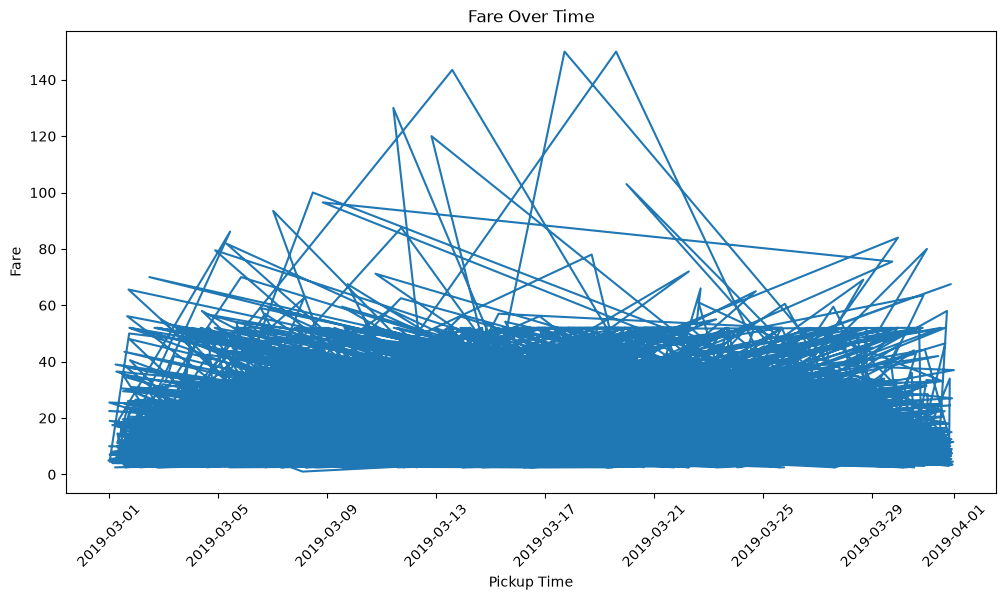

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'])
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=45)
plt.show()

In [9]:
fare_by_borough = df.groupby('pickup_borough')['fare'].sum()

fare_by_borough

pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64

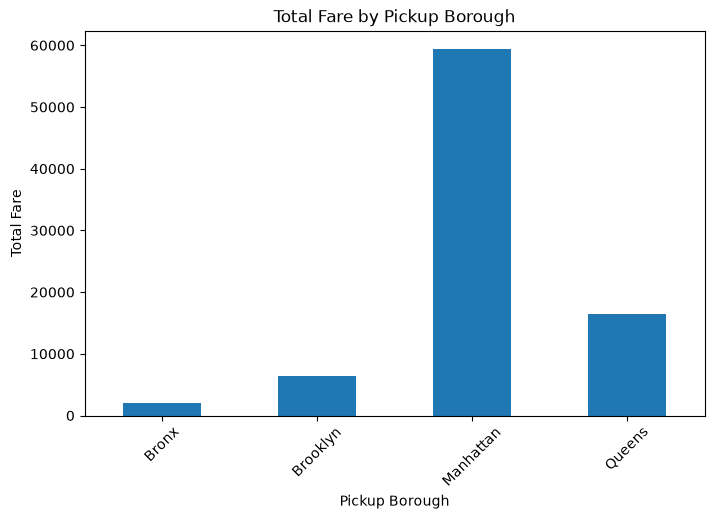

In [10]:
fare_by_borough.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.show()


In [11]:
payment_counts = df['payment'].value_counts()

payment_counts

payment
credit card    4621
cash           1812
Name: count, dtype: int64

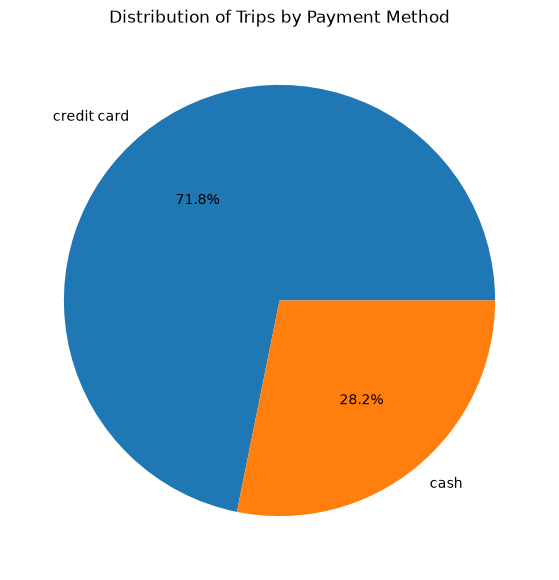

In [12]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Trips by Payment Method')
plt.show()

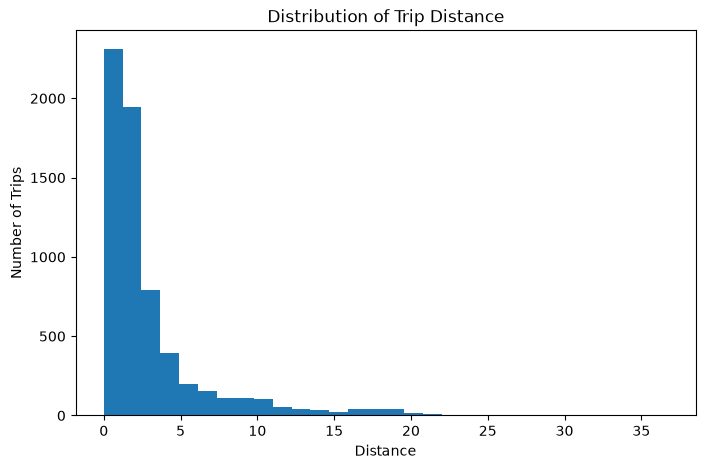

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=30)

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Distance')

plt.show()

<Figure size 1000x600 with 0 Axes>

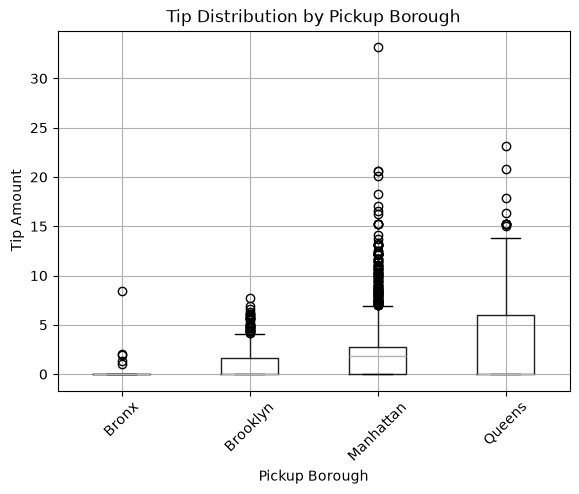

In [14]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column='tip',
    by='pickup_borough'
)

plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Tip Distribution by Pickup Borough')
plt.suptitle('')

plt.xticks(rotation=45)
plt.show()

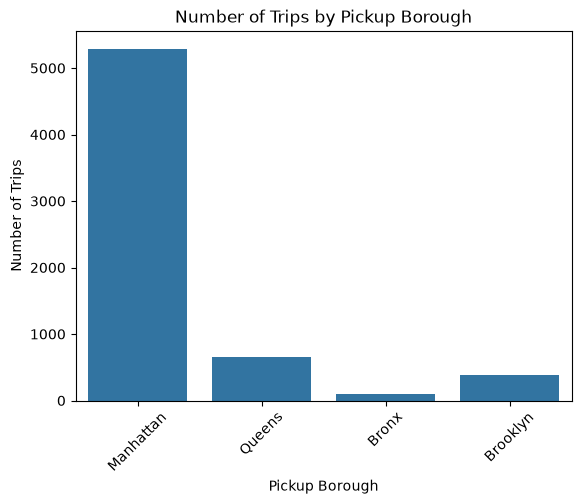

In [15]:
sns.countplot(data=df, x='pickup_borough')

plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')
plt.xticks(rotation=45)

plt.show()

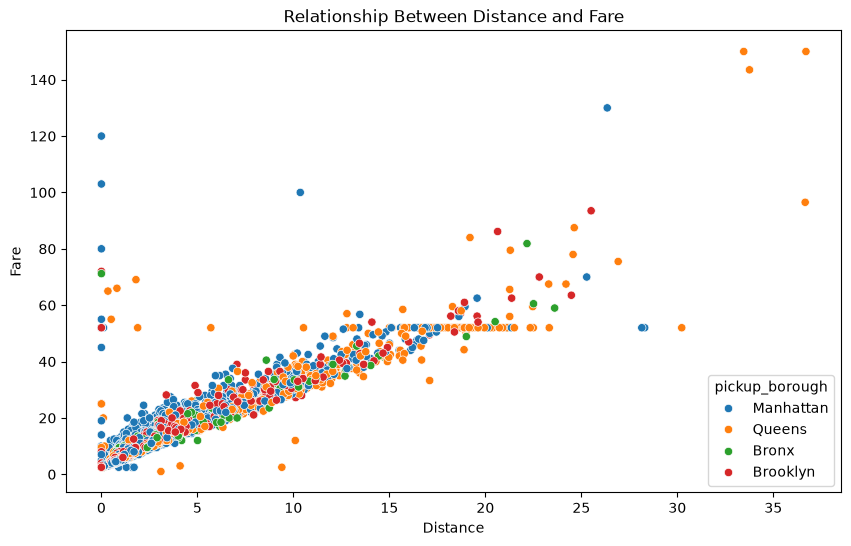

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')

plt.show()

In [17]:
correlation = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

correlation


,distance,fare,tip,tolls,total
distance,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.904676,0.974358,0.646186,0.683142,1.000000


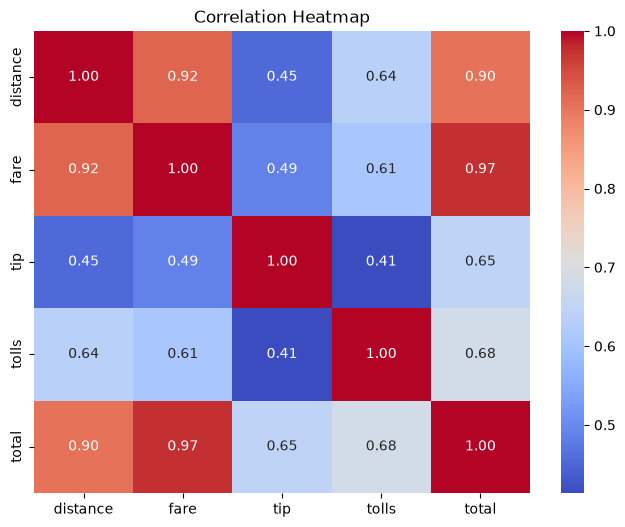

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


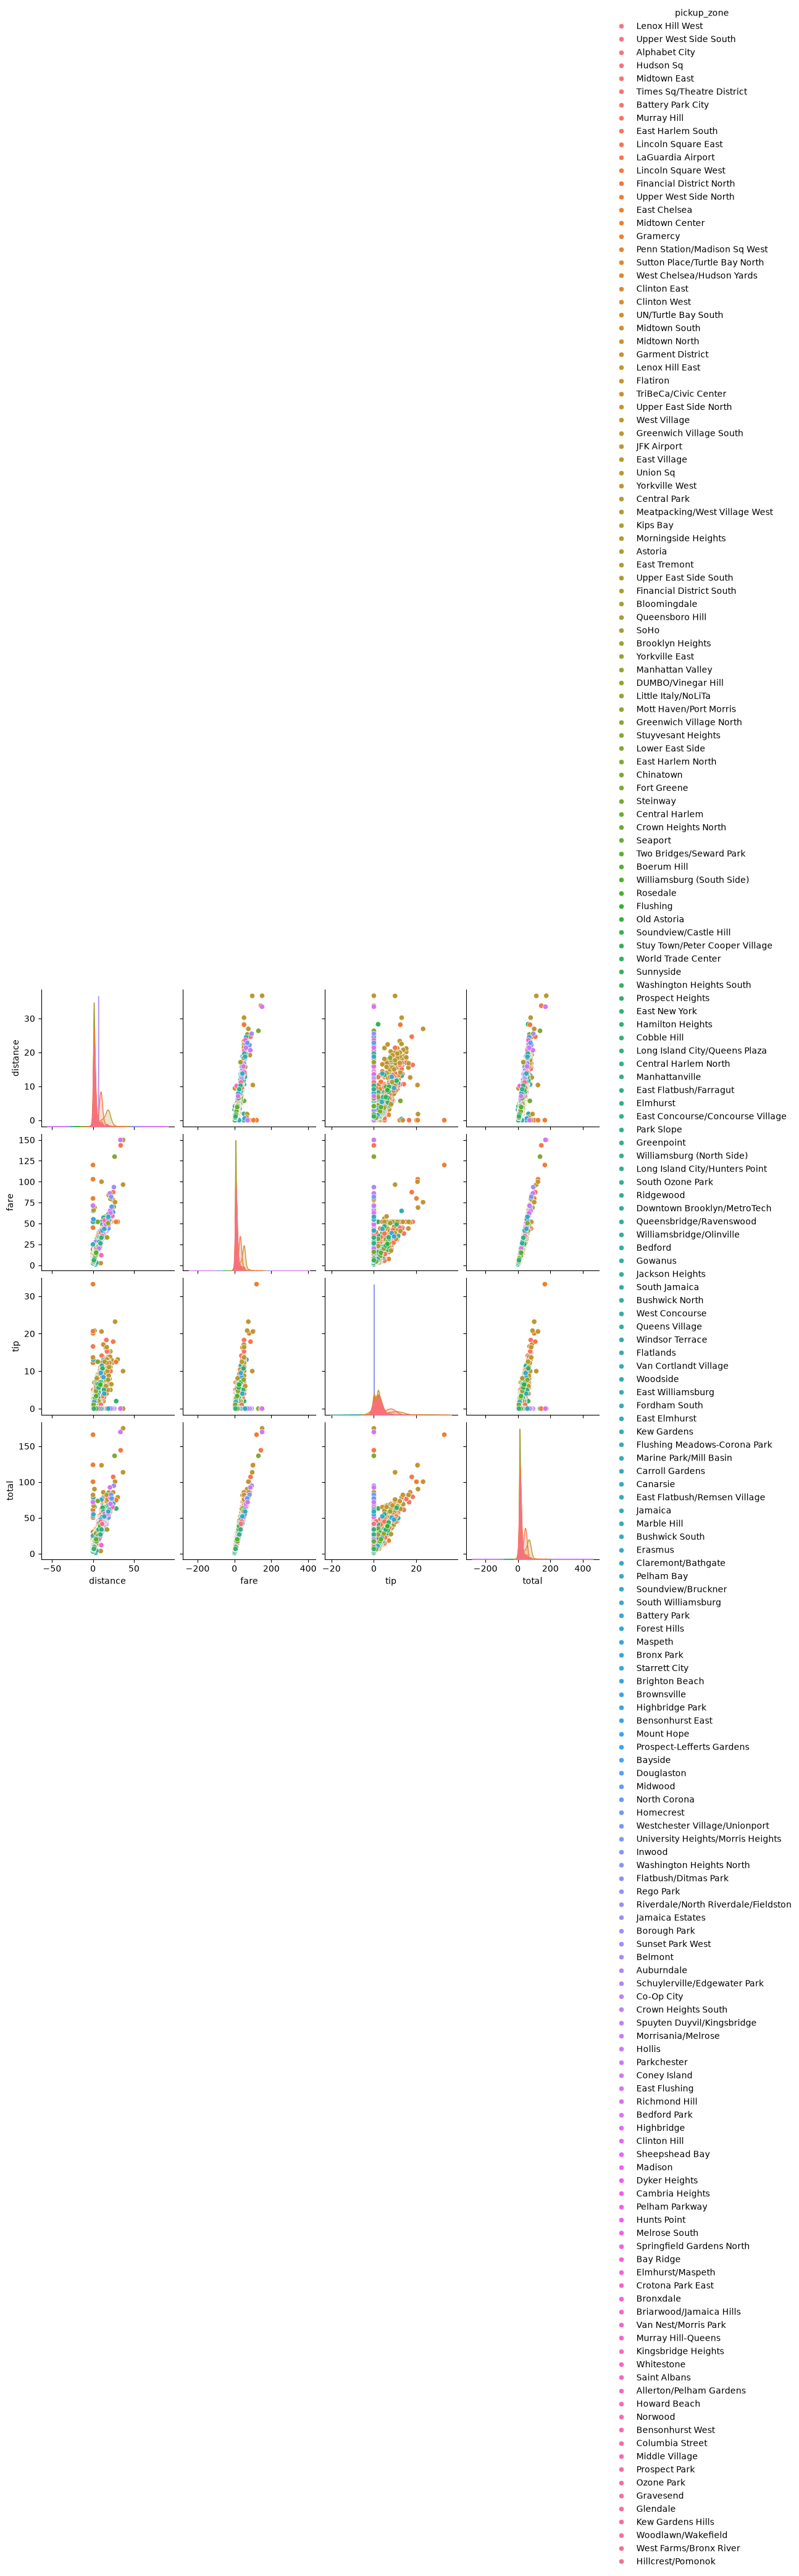

In [19]:
pair_data = df[['distance', 'fare', 'tip', 'total', 'pickup_zone']].dropna()

sns.pairplot(
    pair_data,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

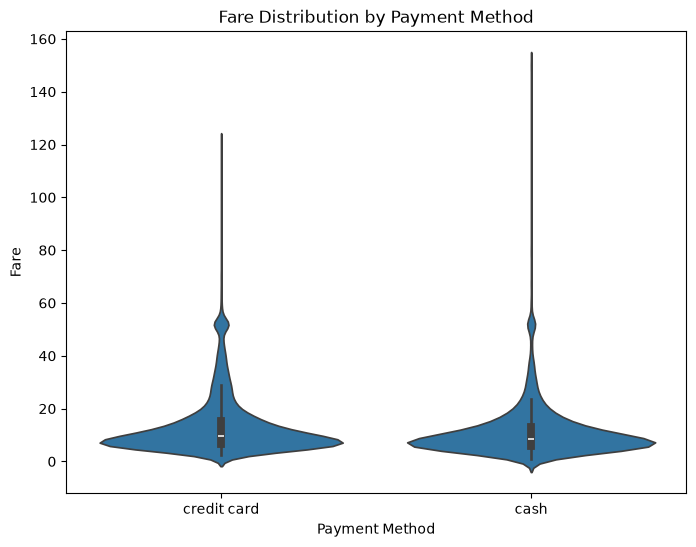

In [20]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')

plt.show()